# Session 06 - Brief Look into GETTSIM

In session 06, we discuss [gettsim](https://gettsim.readthedocs.io/en/stable/)  - an open source python based microsimulation model for the German Tax and Transfer System (TTS). 

1. **Preamble:** Import packages and check environment.
2. **Understanding the German TTS:** Use DAG structure to visualize TTS, and inspect different nodes.
3. **Simulate Example Policy:** Simulate social insurance contributions for UI.
4. **Simulate TTS:** Simulate taxes, transfers, and social insurance contributions.

# Preamble

This part imports python packages used in this script. Note that some packages do not come with the Anaconda distribution and thus need to be installed in your environment via Terminal/Anaconda Prompt:

```
conda activate <environment>
conda install <packagename>
```

In [1]:
# Import other packages 

import pandas as pd        # import pandas (data manipulation)
import numpy as np         # numerical computations
import inspect             # inspect elements of gettsim
import matplotlib.pyplot as plt # plotting

# Import gettsim package 

import gettsim             # import gettsim package 
from gettsim import InputData, MainTarget, TTTargets, copy_environment, main, tt, Labels, plot # modules within gettsim

# Check version of gettsim

print(gettsim.__version__) # check version

1.1.1


In [2]:
# Check in which environment you are

import sys
sys.executable

'/opt/anaconda3/envs/microsimulation/bin/python'

In [3]:
# Getting help for commands

# help(pd.DataFrame)

# Understanding the German TTS

To understand the complexities of the German TTS, we can visualize the gettsim simulations as a DAG. We can then further inspect particular nodes of interest and thereby understand the policy function behind each node.

## Visualization

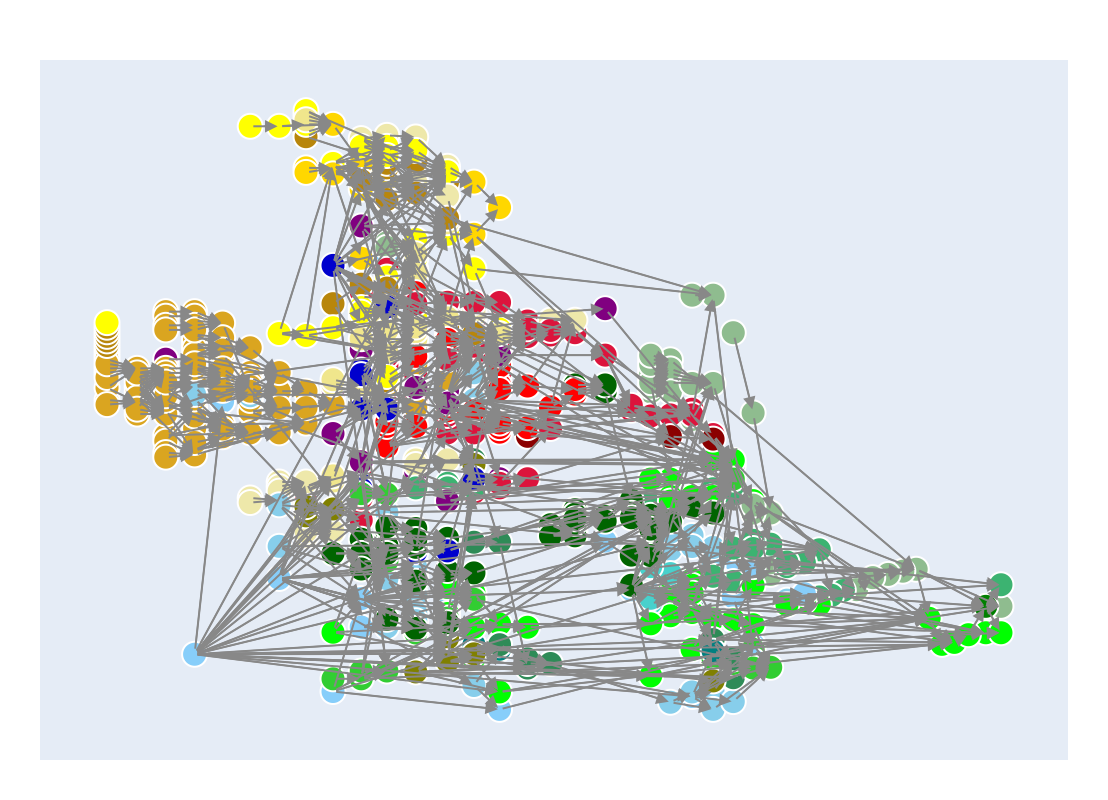

In [4]:
# Visualize Full Tax and Transfer System at a specific date 
 
fig01 = plot.dag.tt(policy_date_str="2025-01-01", width=1200, height=800, show_node_description = True)

# Export figure

fig01.write_image("../03-output/gr_session06_01_gettsim_dag_2025.pdf") 

# Show figure inline

fig01

In [5]:
# See colorcoding in documentation

plot.dag.tt?

Signature:
plot.dag.tt(
    *,
    primary_nodes: 'set[str] | set[tuple[str, str]] | None' = None,
    selection_type: "Literal['neighbors', 'descendants', 'ancestors', 'all_paths'] | None" = None,
    selection_depth: 'int | None' = None,
    include_params: 'bool' = True,
    show_node_description: 'bool' = False,
    output_path: 'Path | None' = None,
    node_colormap: 'dict[tuple[str, ...], str] | None' = {('top-level',): 'lightskyblue', ('einnahmen',): 'mediumblue', ('familie',): 'skyblue', ('wohnen',): 'mediumturquoise', ('hh_characteristics',): 'skyblue', ('ids',): 'deepskyblue', ('unterhalt',): 'teal', ('einkommensteuer',): 'crimson', ('einkommensteuer', 'einkünfte'): 'purple', ('lohnsteuer',): 'red', ('solidaritätszuschlag',): 'darkred', ('sozialversicherung',): 'gold', ('sozialversicherung', 'arbeitslosen'): 'palegoldenrod', ('sozialversicherung', 'kranken'): 'yellow', ('sozialversicherung', 'pflege'): 'khaki', ('sozialversicherung', 'rente'): 'goldenrod', ('sozialversicheru

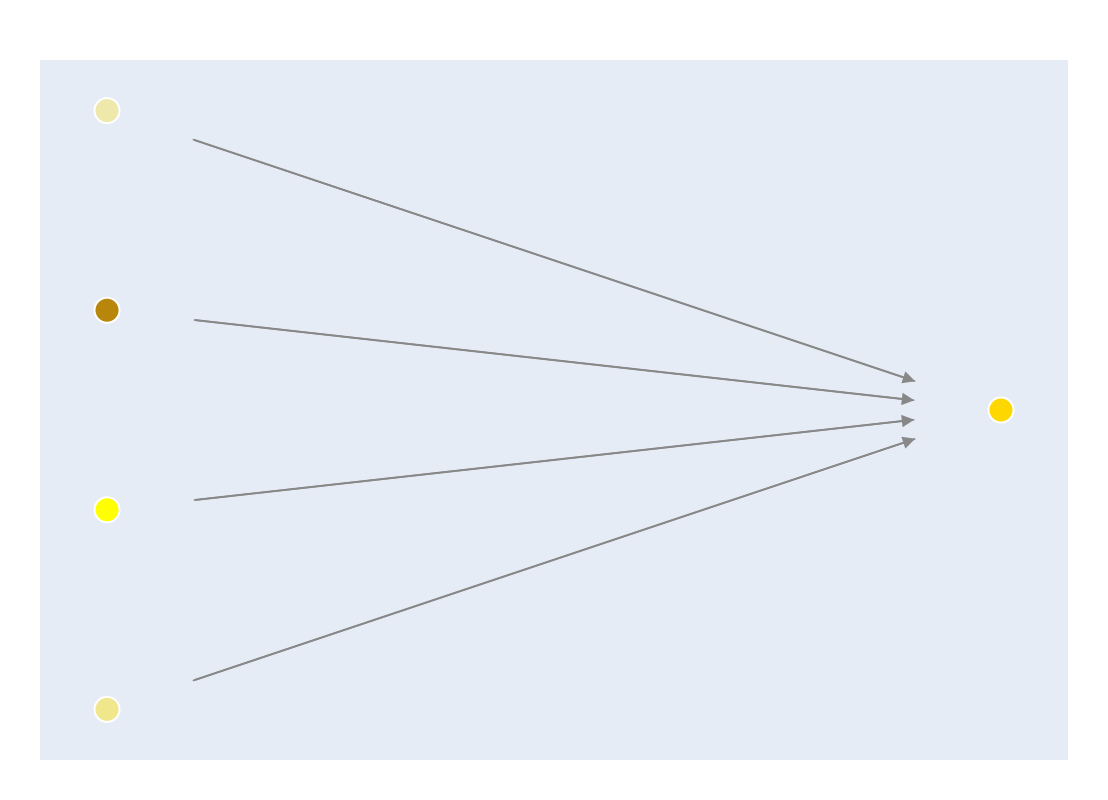

In [6]:
# Visualization also possible for part of the system

# Example 1: 
# What are the direct input variables necessary for the computation of social insurance contributions?

fig02 = plot.dag.tt(
    policy_date_str="2025-01-01", # policy date 
    primary_nodes={"sozialversicherung__beiträge_versicherter_m"}, # node (point) of interest
    selection_type="ancestors", # look only backwards from the node 
    selection_depth=1, # look only one step backward
    width=1200, # graph width 
    height=800, # graph height 
    show_node_description = True) # show description of nodes

#fig02.write_image("../03-output/gr_session06_02_gettsim_dag_socialinsurance_2025.pdf")

fig02

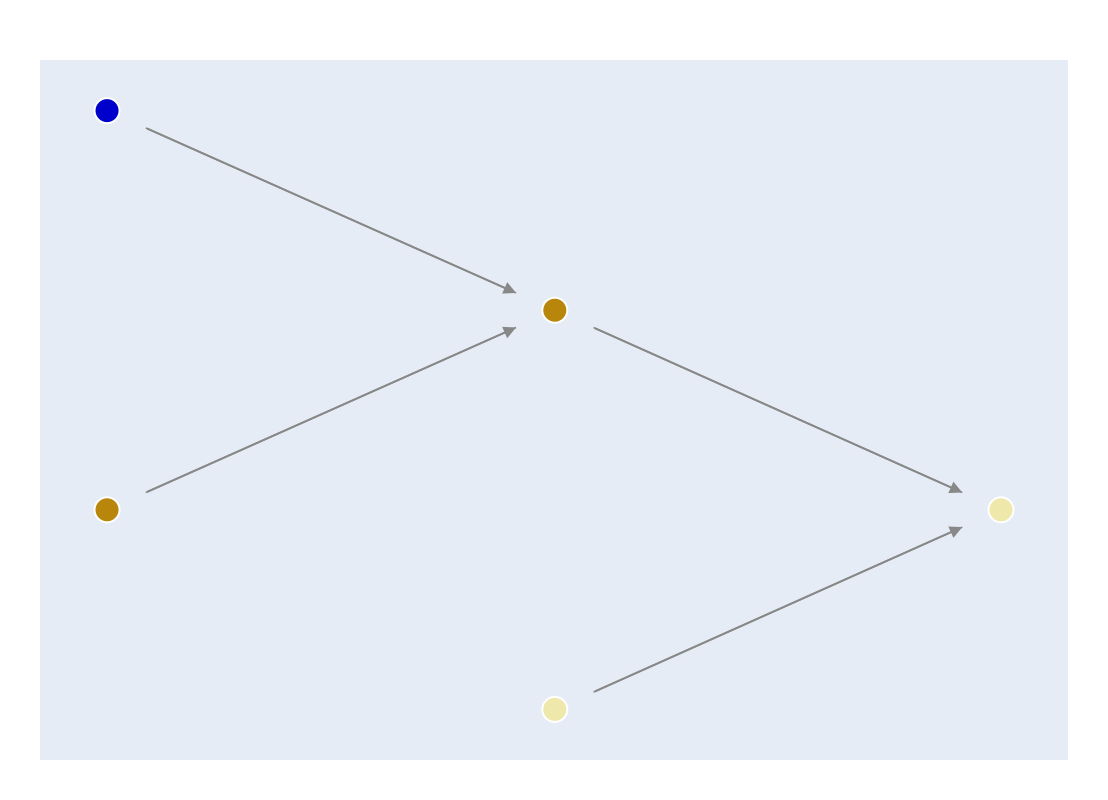

In [7]:
# Example 2:
# Now check the full path leading to the social insurance contribution for pension payments

plot.dag.tt(
    policy_date_str="1970-01-01",
    primary_nodes={"sozialversicherung__arbeitslosen__beitrag__betrag_versicherter_m"},
    selection_type="ancestors",
    width=1200,
    height=800,
    show_node_description = True)

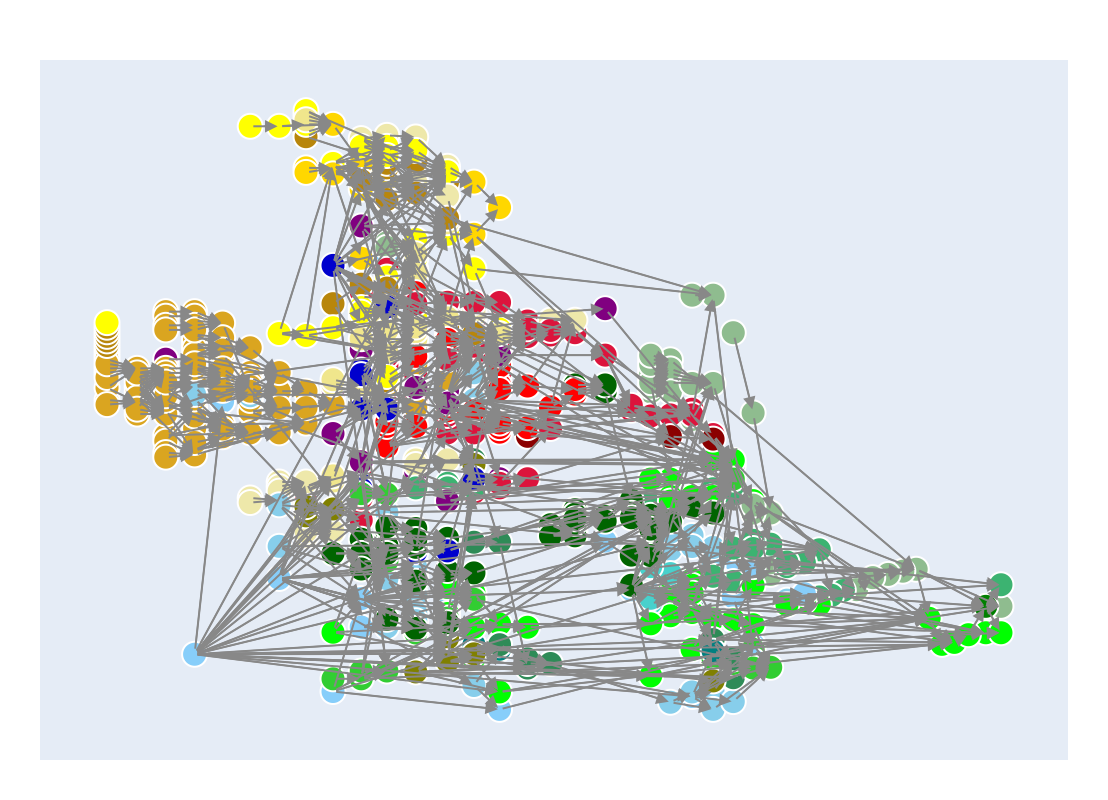

In [8]:
# Example 3: Bürgergeld

plot.dag.tt(
    policy_date_str="2025-01-01",
    primary_nodes={"bürgergeld__betrag_m_bg"},
    width=1200,
    height=800,
    show_node_description = True)

## Inspect Nodes

In [9]:
# Define policy environment 

pe = main(
    main_target=MainTarget.policy_environment,
    policy_date_str="2025-01-01",
)

# Define function that gives for specific policy environment and node object

def get_from_pe(policy_environment, node_name: str):
    obj = policy_environment
    for key in node_name.split("__"):
        obj = obj[key]
    return obj

In [10]:
# Example node: 

nodename = "sozialversicherung__beiträge_versicherter_m" 
obj = get_from_pe(pe, nodename)

# See class of object 

print(type(obj)) 

# -> In our case here, node is defined as a policy function 

<class 'ttsim.tt.column_objects_param_function.PolicyFunction'>


In [11]:
# See description of node object 

print(obj.description)

Sum of social insurance contributions paid by the insured person.


In [12]:
# See parents/ancestors of node 

obj.dependencies

{'arbeitslosen__beitrag__betrag_versicherter_m',
 'kranken__beitrag__betrag_versicherter_m',
 'pflege__beitrag__betrag_versicherter_m',
 'rente__beitrag__betrag_versicherter_m'}

In [13]:
# See definition of node (how do we get from inputs to the node output) - basically the edges

print(inspect.getsource(obj.function))   # the definition of the node 

@policy_function()
def beiträge_versicherter_m(
    pflege__beitrag__betrag_versicherter_m: float,
    kranken__beitrag__betrag_versicherter_m: float,
    rente__beitrag__betrag_versicherter_m: float,
    arbeitslosen__beitrag__betrag_versicherter_m: float,
) -> float:
    """Sum of social insurance contributions paid by the insured person."""
    return (
        pflege__beitrag__betrag_versicherter_m
        + kranken__beitrag__betrag_versicherter_m
        + rente__beitrag__betrag_versicherter_m
        + arbeitslosen__beitrag__betrag_versicherter_m
    )



In [14]:
# Let's take a look at another node

nodename = "sozialversicherung__arbeitslosen__beitrag__betrag_versicherter_m"
obj = get_from_pe(pe, nodename)

print(type(obj))
print("")
print(obj.description)
print("")
print(obj.dependencies)
print("")
print(inspect.getsource(obj.function)) 

<class 'ttsim.tt.column_objects_param_function.PolicyFunction'>

Unemployment insurance contributions paid by the insured person.

{'beitragssatz', 'sozialversicherung__geringfügig_beschäftigt', 'betrag_versicherter_in_gleitzone_m', 'sozialversicherung__rente__beitrag__einkommen_m', 'sozialversicherung__in_gleitzone'}

@policy_function(start_date="2003-04-01", leaf_name="betrag_versicherter_m")
def betrag_versicherter_m_mit_midijob(
    sozialversicherung__geringfügig_beschäftigt: bool,
    sozialversicherung__in_gleitzone: bool,
    betrag_versicherter_in_gleitzone_m: float,
    sozialversicherung__rente__beitrag__einkommen_m: float,
    beitragssatz: float,
) -> float:
    """Unemployment insurance contributions paid by the insured person."""
    if sozialversicherung__geringfügig_beschäftigt:
        out = 0.0
    elif sozialversicherung__in_gleitzone:
        out = betrag_versicherter_in_gleitzone_m
    else:
        out = sozialversicherung__rente__beitrag__einkommen_m * beitragss

In [15]:
# Not all nodes are functions:

# Example: PolicyInput

nodename = "alter"
obj = get_from_pe(pe,nodename)

print(type(obj))
print("")
print(obj.description)
print("")
print(obj.data_type)
print("")

# -> this is a policy input, has a data_type (integer)

<class 'ttsim.tt.column_objects_param_function.PolicyInput'>

Age in years.

int



In [16]:
# Not all nodes are functions:

# Example: DictParam (Parameter)

nodename = "sozialversicherung__kranken__beitrag__parameter_beitragssatz"

obj = get_from_pe(pe,nodename)

print(type(obj))
print("")
print(obj.description)
print("")
print(obj.value)
print("")
print(obj.unit)
print("")

# -> this is a policy input, has a particular value (or multiple values) for a specific policy environment

<class 'ttsim.tt.param_objects.DictParam'>

{'de': 'Beitragssätze für gesetzliche Krankenversicherung. mean_allgemein - durchschnittlicher Beitragssatz, bis 2008 allgemein - allgemeiner Satz (§241 SGB V), ab 2009 sonderbeitrag - bezahlt von Arbeitnehmern, ab Jul 2005 bis 2014 ermäßigt - ermäßigter Satz (§243 SGB V) zusatz - durchschnittlicher Zusatzbeitragssatz.', 'en': 'Statury Contribution Rates for mandatory health insurance. mean_allgemein - average contribution rate, 1992 to 2008 allgemein - general statutory contribution rate, since 2009 sonderbeitrag - paid by employees, Jul 2005 to 2014 ermäßigt - reduced rate zusatz - average top-up contribution rate'}

{'allgemein': 0.146, 'ermäßigt': 0.14, 'mean_zusatzbeitrag': 0.025}

Share



In [17]:
# Parameters can be checked for multiple policy environments

pe = main(
    main_target=MainTarget.policy_environment,
    policy_date_str="2010-01-01",
)

nodename = "sozialversicherung__kranken__beitrag__parameter_beitragssatz"

obj = get_from_pe(pe,nodename)

print(type(obj))
print("")
print(obj.description)
print("")
print(obj.value)
print("")
print(obj.unit)
print("")

# -> this is a policy input, has a particular value (or multiple values) for a specific policy environment

<class 'ttsim.tt.param_objects.DictParam'>

{'de': 'Beitragssätze für gesetzliche Krankenversicherung. mean_allgemein - durchschnittlicher Beitragssatz, bis 2008 allgemein - allgemeiner Satz (§241 SGB V), ab 2009 sonderbeitrag - bezahlt von Arbeitnehmern, ab Jul 2005 bis 2014 ermäßigt - ermäßigter Satz (§243 SGB V) zusatz - durchschnittlicher Zusatzbeitragssatz.', 'en': 'Statury Contribution Rates for mandatory health insurance. mean_allgemein - average contribution rate, 1992 to 2008 allgemein - general statutory contribution rate, since 2009 sonderbeitrag - paid by employees, Jul 2005 to 2014 ermäßigt - reduced rate zusatz - average top-up contribution rate'}

{'allgemein': 0.14, 'sonderbeitrag': 0.009, 'ermäßigt': 0.134}

Share



In [18]:
nodename = "einkommensteuer__betrag_ohne_kinderfreibetrag_y_sn"
obj = get_from_pe(pe,nodename)

print(type(obj))
print("")
print(obj.description)
print("")
print(obj.dependencies)
print("")
print(inspect.getsource(obj.function)) 

<class 'ttsim.tt.column_objects_param_function.PolicyFunction'>

Taxes without child allowance on Steuernummer level. Also referred to as
"tarifliche ESt II".

{'parameter_einkommensteuertarif', 'familie__anzahl_personen_sn', 'xnp', 'gesamteinkommen_y'}

@policy_function(
    rounding_spec=RoundingSpec(
        base=1,
        direction="down",
        reference="§ 32a Abs. 1 S.6 EStG",
    ),
)
def betrag_ohne_kinderfreibetrag_y_sn(
    gesamteinkommen_y: float,
    familie__anzahl_personen_sn: int,
    parameter_einkommensteuertarif: PiecewisePolynomialParamValue,
    xnp: ModuleType,
) -> float:
    """Taxes without child allowance on Steuernummer level. Also referred to as
    "tarifliche ESt II".

    """
    zu_verst_eink_per_indiv = gesamteinkommen_y / familie__anzahl_personen_sn
    return familie__anzahl_personen_sn * piecewise_polynomial(
        x=zu_verst_eink_per_indiv,
        parameters=parameter_einkommensteuertarif,
        xnp=xnp,
    )



In [19]:
nodename = "einkommensteuer__parameter_einkommensteuertarif"
obj = get_from_pe(pe,nodename)

print(type(obj))
print("")
print(obj.description)
print("")
print(obj.dependencies)
print("")
print(inspect.getsource(obj.function)) 

<class 'ttsim.tt.column_objects_param_function.ParamFunction'>

Add the quadratic terms to tax tariff function.

The German tax tariff is defined on several income intervals with distinct
marginal tax rates at the thresholds. To ensure an almost linear increase of
the average tax rate, the German tax tariff is defined as a quadratic function,
where the quadratic rate is the so called linear Progressionsfaktor. For its
calculation one needs the lower (low_thres) and upper (upper_thres) thresholds of
the interval as well as the marginal tax rate of the interval (rate_iv) and of the
following interval (rate_fiv). The formula is then given by:

(rate_fiv - rate_iv) / (2 * (upper_thres - low_thres))

{'xnp', 'raw_parameter_einkommensteuertarif'}

@param_function(start_date="2002-01-01")
def parameter_einkommensteuertarif(
    raw_parameter_einkommensteuertarif: RawParamValue,
    xnp: ModuleType,
) -> PiecewisePolynomialParamValue:
    """Add the quadratic terms to tax tariff function.

   

# Simulate Example Policy

Suppose we want to calculate SIC for unemployment insurance for a particular household. The DAG above tells us which components are needed. To simulate, we

1. Define Targets
2. Generate Data, i.e., the Households
3. Simulate Targets for Data under Policy Environment

## Define Targets

In [20]:
# Specify Targets (here only individual contribution to unemployment insurance)

TT_TARGETS = {
    "sozialversicherung": {
        "arbeitslosen": {
            "beitrag": {
                "betrag_versicherter_m": "unemployment_insurance_contribution_m" # the last part is the name that we assign 
            }
        },
    },
}

In [21]:
internal_name = TT_TARGETS["sozialversicherung"]["arbeitslosen"]["beitrag"]["betrag_versicherter_m"]

In [22]:
internal_name

'unemployment_insurance_contribution_m'

In [23]:
# What input variables are needed to estimate contribution to unemployment insurance 

main(
    main_target=MainTarget.templates.input_data_dtypes.tree,
    policy_date_str="2025-01-01",
    tt_targets=TTTargets.tree(TT_TARGETS),
    include_warn_nodes=False,
)

{'einnahmen': {'bruttolohn_m': 'FloatColumn'}}

## Example Household

In [24]:
# Specify example household:

# hh_id and p_id always required 

DATA = pd.DataFrame(
    {
        "hh_id": [0],
        "p_id": [0],
        "income_from_employment": [5000],
    }
)

# alternative household with children 

DATA_ALT = pd.DataFrame(
    {
        "hh_id": [0,0,0],
        "p_id": [0,1,2],
        "age": [45,16,14],
        "income_from_employment": [5000,0,0],
    }
)

# Define mapping from data variable names to GETTSIM data names 

MAPPER = {
    "hh_id": "hh_id",
    "p_id": "p_id",
    "einnahmen": {
        "bruttolohn_m": "income_from_employment",
    },
}

# Estimate results 

result = main(
    main_target=MainTarget.results.df_with_mapper,
    policy_date_str="2025-01-01",
    input_data=InputData.df_and_mapper(
        df=DATA,
        mapper=MAPPER,
    ),
    tt_targets=TTTargets.tree(TT_TARGETS),
    include_warn_nodes=False,
)
result.T

p_id,0
unemployment_insurance_contribution_m,65.0


## Example Household with Varying Earnings

In [25]:
earnings = np.arange(0, 40001, 100)

DATA = pd.DataFrame({
    "hh_id": np.arange(len(earnings)),
    "p_id": np.arange(len(earnings)),
    "income_from_employment": earnings
})

# Estimate results 

result = main(
    main_target=MainTarget.results.df_with_mapper,
    policy_date_str="2025-01-01",
    input_data=InputData.df_and_mapper(
        df=DATA,
        mapper=MAPPER,
    ),
    tt_targets=TTTargets.tree(TT_TARGETS),
    include_warn_nodes=False,
)
result.head()

,unemployment_insurance_contribution_m
p_id,
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


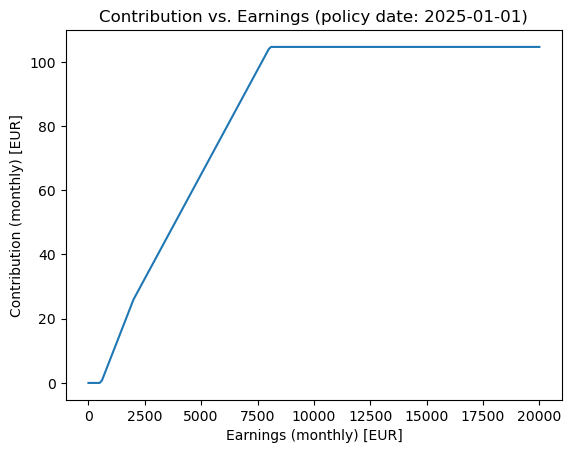

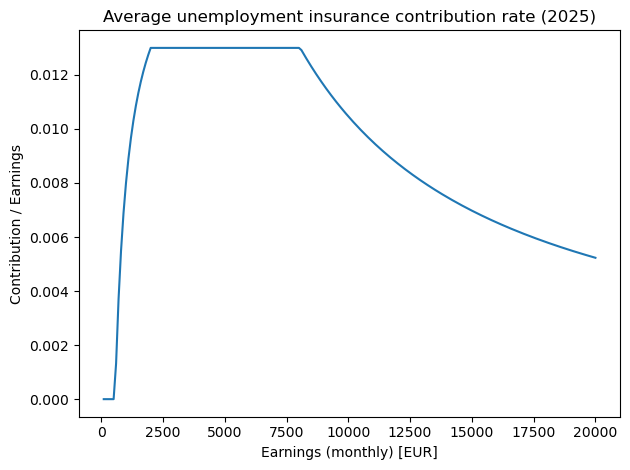

In [26]:
x = earnings
y = result["unemployment_insurance_contribution_m"]   # <-- replace with your column name

mask = x <= 20_000

plt.figure()
plt.plot(x[mask], y[mask])
plt.xlabel("Earnings (monthly) [EUR]")
plt.ylabel("Contribution (monthly) [EUR]")
plt.title("Contribution vs. Earnings (policy date: 2025-01-01)")

plt.savefig("../03-output/gr_session06_03_gettsim_dag_unemploymentcontribution_abs_2025.pdf")
plt.show()


relative_payment = y[mask] / x[mask]

fig, ax = plt.subplots()
ax.plot(x[mask], relative_payment)
ax.set_xlabel("Earnings (monthly) [EUR]")
ax.set_ylabel("Contribution / Earnings")
ax.set_title("Average unemployment insurance contribution rate (2025)")

fig.tight_layout()
fig.savefig("../03-output/gr_session06_04_gettsim_dag_unemploymentcontribution_rel_2025.pdf")
plt.show()

# Simulate TTS

The simulation of multiple components of the TTS as targets requires much more inputs than the simple example for UI contributions above.

## Define Targets

In [27]:
# Check which variables are needed 

TT_TARGETS = {
    "einkommensteuer": {
        "betrag_y_sn": "annual_tax_taxunit" # the last part is the name that we assign 
    },
     "sozialversicherung": {
        "arbeitslosen": {
            "beitrag": {
                "betrag_versicherter_y": "unemployment_insurance_contribution_y", # the last part is the name that we assign 
            }
        },
        "kranken": {
            "beitrag": {
                "betrag_versicherter_y": "health_insurance_contribution_y", # the last part is the name that we assign 
            }
        },
        "pflege": {
            "beitrag": {
                "betrag_versicherter_y": "longtermcare_insurance_contribution_y", # the last part is the name that we assign 
            }
        },
        "rente": {
            "beitrag": {
                "betrag_versicherter_y": "pension_insurance_contribution_y", # the last part is the name that we assign 
            }
        }
    },
    "bürgergeld": {
        "betrag_y_bg": "transfer_subsistence_y_bg",
    },
    "wohngeld": {
        "betrag_y_wthh": "transfer_housing_y_hh",
    },
    "kinderzuschlag": {
        "betrag_y_bg": "transfer_child_y_bg",
    }
}

# What input variables are needed to estimate contribution to unemployment insurance 

main(
    main_target=MainTarget.templates.input_data_dtypes.tree,
    policy_date_str="2025-01-01",
    tt_targets=TTTargets.tree(TT_TARGETS),
    include_warn_nodes=False,
)


{'alter': 'IntColumn',
 'alter_monate': 'IntColumn',
 'arbeitsstunden_w': 'FloatColumn',
 'behinderungsgrad': 'IntColumn',
 'bürgergeld': {'bezug_im_vorjahr': 'BoolColumn',
  'p_id_einstandspartner': 'IntColumn'},
 'einkommensteuer': {'abzüge': {'beitrag_private_rentenversicherung_m': 'FloatColumn',
   'kinderbetreuungskosten_m': 'FloatColumn',
   'p_id_kinderbetreuungskostenträger': 'IntColumn'},
  'einkünfte': {'aus_forst_und_landwirtschaft': {'betrag_y': 'FloatColumn'},
   'aus_gewerbebetrieb': {'betrag_y': 'FloatColumn'},
   'aus_selbstständiger_arbeit': {'betrag_y': 'FloatColumn'},
   'aus_vermietung_und_verpachtung': {'betrag_y': 'FloatColumn'},
   'ist_hauptberuflich_selbstständig': 'BoolColumn',
   'sonstige': {'alle_weiteren_y': 'FloatColumn',
    'rente': {'alter_beginn_leistungsbezug_sonstige_private_vorsorge': 'IntColumn'}}},
  'gemeinsam_veranlagt': 'BoolColumn'},
 'einnahmen': {'bruttolohn_m': 'FloatColumn',
  'kapitalerträge_y': 'FloatColumn',
  'renten': {'aus_berufsstä

In [28]:
# Define policy environment of interest 

pe = main(
    main_target=MainTarget.policy_environment,
    policy_date_str="2025-01-01",
    backend="numpy",
)


nodename = "wohngeld__mietstufe_hh"
obj = get_from_pe(pe, nodename)

obj.description
obj.docstring


"Municipality's rent classification."

In [29]:
nodename = "unterhalt__tatsächlich_erhaltener_betrag_m"

obj = get_from_pe(pe, nodename)

obj.description
obj.docstring

'Alimony payments the recipient actually receives.'

In [30]:
nodename = "bürgergeld__bezug_im_vorjahr"
nodename = "alter_monate"
nodename = "bürgergeld__p_id_einstandspartner"

obj = get_from_pe(pe, nodename)

obj.description
obj.docstring

'Identifier of Einstandspartner.'

## Define Input Data

In [31]:
INPUT_DATA = {
    "alter": np.array([40]),
    "alter_monate": np.array([40*12]),
    "arbeitsstunden_w": np.array([40]),
    "behinderungsgrad": np.array([0]),
    "einnahmen": {
        "bruttolohn_m": np.array([0]),
        "kapitalerträge_m": np.array([0.0]),
        "renten": {
            "gesamt_m": np.array([0.0]),
        },
    },
    "lohnsteuer": {
        "steuerklasse": np.array([1]),
    },
    "einkommensteuer": {
        "abzüge": {
            "beitrag_private_rentenversicherung_m": np.array([0]),
            "kinderbetreuungskosten_m": np.array([0.0]),
            "p_id_kinderbetreuungskostenträger": np.array([-1]),
        },
        "einkünfte": {
            "aus_forst_und_landwirtschaft": {"betrag_m": np.array([0.0])},
            "aus_gewerbebetrieb": {"betrag_m": np.array([0.0])},
            "aus_selbstständiger_arbeit": {"betrag_m": np.array([0.0])},
            "aus_vermietung_und_verpachtung": {"betrag_m": np.array([0.0])},
            "ist_hauptberuflich_selbstständig": np.array([False]),
            "sonstige": {
                "alle_weiteren_m": np.array([0.0]),
                "rente": {"betrag_m": np.array([0.0])},
            },
        },
        "gemeinsam_veranlagt": np.array([False]),
    },
    "bürgergeld": {
        "p_id_einstandspartner": np.array([-1]),
        "bezug_im_vorjahr": np.array([False]),
    }, 
    "wohngeld": {
        "mietstufe_hh": np.array([6]),
    },
    "wohnen": {
        "bruttokaltmiete_m_hh": np.array([600]),
        "bewohnt_eigentum_hh": np.array([False]),
        "heizkosten_m_hh": np.array([60]),
        "wohnfläche_hh": np.array([60]),
    },
    "vermögen_wthh": np.array([0]),
    "vermögen_bg": np.array([0]),
    "familie": {
        "alleinerziehend": np.array([False]),
        "p_id_ehepartner": np.array([-1]),
        "p_id_elternteil_1": np.array([-1]),
        "p_id_elternteil_2": np.array([-1]),
    },
    "elterngeld": {
        "zu_versteuerndes_einkommen_vorjahr_y_sn": np.array([0]),
        "mean_nettoeinkommen_in_12_monaten_vor_geburt_m": np.array([0]),
        "claimed": np.array([False]),
        "bisherige_bezugsmonate": np.array([0]),
        "bisherige_bezugsmonate_fg": np.array([0]),
    },
    "geburtsjahr": np.array([1985]),
    "unterhalt": {
        "tatsächlich_erhaltener_betrag_m": np.array([0]),
    },
    "kindergeld": {
        "in_ausbildung": np.array([False]),
        "p_id_empfänger": np.array([-1]),
    },
    "p_id": np.array([0]),
    "hh_id": np.array([0]),
    "sozialversicherung": {
        "kranken": {
            "beitrag": {
                "privat_versichert": np.array([False]),
                "bemessungsgrundlage_rente_m": np.array([0.0]),
            },
        },
        "pflege": {"beitrag": {"hat_kinder": np.array([True])}},
        "rente": {
            "altersrente": {"betrag_m": np.array([0.0])},
            "erwerbsminderung": {"betrag_m": np.array([0.0])},
            "jahr_renteneintritt": np.array([2060]),
            "bezieht_rente": np.array([False]),
        },
        "arbeitslosen": {
            "mean_nettoeinkommen_in_12_monaten_vor_arbeitslosigkeit_m": np.array([0]),
            "arbeitssuchend": np.array([False]),
            "monate_beitragspflichtig_versichert_in_letzten_30_monaten": np.array([0]),
            "monate_sozialversicherungspflichtiger_beschäftigung_in_letzten_5_jahren": np.array([0]),
            "monate_durchgängigen_bezugs_von_arbeitslosengeld": np.array([0]),
        },
    },
}

In [32]:
# Calculate Output

main(
    main_target=MainTarget.results.df_with_nested_columns,
    policy_date_str="2025-01-01",
    input_data=InputData.tree(INPUT_DATA),
    tt_targets=TTTargets.tree(TT_TARGETS),
    include_warn_nodes=False,
)

einkommensteuer    sozialversicherung                        \
         betrag_y_sn          arbeitslosen               kranken   
                 NaN               beitrag               beitrag   
                 NaN betrag_versicherter_y betrag_versicherter_y   
p_id                                                               
0                0.0                   0.0                   0.0   

                                                  bürgergeld      wohngeld  \
                    pflege                 rente betrag_y_bg betrag_y_wthh   
                   beitrag               beitrag         NaN           NaN   
     betrag_versicherter_y betrag_versicherter_y         NaN           NaN   
p_id                                                                         
0                      0.0                   0.0     14676.0           0.0   

     kinderzuschlag  
        betrag_y_bg  
                NaN  
                NaN  
p_id                 
0               0.0

In [33]:
earnings = np.arange(0, 20001, 25)
N = len(earnings)

def expand_1_to_N(x, N):
    if isinstance(x, dict):
        return {k: expand_1_to_N(v, N) for k, v in x.items()}
    if isinstance(x, np.ndarray) and x.size == 1:
        return np.repeat(x, N)
    return x

INPUT_DATA_GRID = expand_1_to_N(INPUT_DATA, N)

# vary earnings
INPUT_DATA_GRID["einnahmen"]["bruttolohn_m"] = earnings.astype(float)

# unique ids
INPUT_DATA_GRID["p_id"]  = np.arange(N)
INPUT_DATA_GRID["hh_id"] = np.arange(N)

## Combine Input/Output Data and Export

In [34]:
df_out = main(
    main_target=MainTarget.results.df_with_nested_columns,
    policy_date_str="2025-01-01",
    input_data=InputData.tree(INPUT_DATA_GRID),
    tt_targets=TTTargets.tree(TT_TARGETS),
    include_warn_nodes=False,
)

In [35]:
# Store input data 

df_in = pd.json_normalize(INPUT_DATA_GRID, sep="__")

# If you see list/arrays inside cells, expand to rows:
df_in = df_in.apply(lambda col: pd.Series(col.iloc[0]) if isinstance(col.iloc[0], (list, np.ndarray)) else col)

In [36]:
# Store output data as data frame 

df_out = df_out.reset_index()
df_out.columns = [
    "_".join([str(c) for c in col if isinstance(c, str)])
    if isinstance(col, tuple) else col
    for col in df_out.columns
]

df_out = df_out.rename(columns={
    "p_id___": "p_id",
})

In [37]:
# Merge input and output data

df_merged = (
    df_in
    .merge(
        df_out,
        on="p_id",
        how="left",
        validate="one_to_one",
    )
)

In [38]:
# Export to csv for further processing in R

df_merged.to_csv(
    "../04-data/processed/df_merged.csv",
    index=False
)